<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB0b_Practica_Integradora_20min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica en clase — Recorrido integrador
## Aplica tú el flujo completo: negocio → datos → SQL/EDA → estadística

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

**Duración máxima: 20 minutos.** Trabaja con el **Transportador de Banda** — no lo hemos usado en ningún ejemplo guiado hasta ahora. Puedes apoyarte en un asistente de IA para resolver dudas de sintaxis puntuales, pero la lectura de los resultados la escribes tú.

### Minuto 0-2 · Carga de datos

Ejecuta esta celda (ya resuelta) para generar la flota completa.

In [3]:
import numpy as np
import pandas as pd

# Flota de la planta metalúrgica — el mismo caso que hemos usado desde el Módulo 2.
EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()


,equipo,tbf_horas
0,Bomba Centrífuga,740.602455
1,Bomba Centrífuga,855.912043
2,Bomba Centrífuga,209.477435
3,Bomba Centrífuga,96.626541
4,Bomba Centrífuga,686.733096


### Minuto 2-6 · SQL: extrae y resume tu equipo

**TODO 1:** con DuckDB, escribe una consulta que devuelva, para el **Transportador de Banda**: número de fallas, TBF promedio, mínimo y máximo. Reutiliza el patrón `GROUP BY` + `HAVING` de la notebook de recapitulación.

In [5]:
import duckdb

con = duckdb.connect()
con.register("fallas", fallas)

# TODO 1: consulta SQL con GROUP BY + HAVING para el Transportador de Banda
resumen_sql = con.query("""
    SELECT
        equipo,
        COUNT(tbf_horas) AS numero_fallas,
        AVG(tbf_horas) AS tbf_promedio,
        MIN(tbf_horas) AS tbf_minimo,
        MAX(tbf_horas) AS tbf_maximo
    FROM
        fallas
    GROUP BY
        equipo
    HAVING
        equipo = 'Transportador de Banda'
""").fetchdf()
display(resumen_sql)

,equipo,numero_fallas,tbf_promedio,tbf_minimo,tbf_maximo
0,Transportador de Banda,58,1024.291293,39.554097,4947.309738


### Minuto 6-10 · EDA visual

**TODO 2:** genera un boxplot del TBF del Transportador de Banda (puedes usar `sns.boxplot`, con los colores de marca `#9B004C` / `#F4EEF1`).

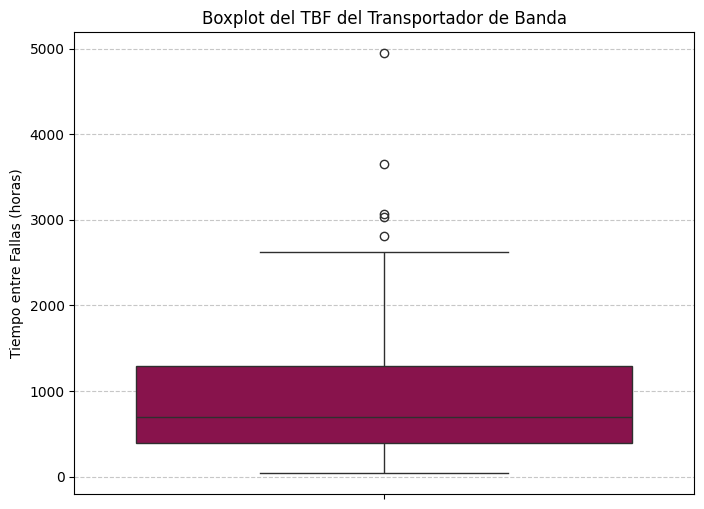

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

transportador = fallas[fallas["equipo"] == "Transportador de Banda"]["tbf_horas"]

# TODO 2: boxplot de `transportador`
plt.figure(figsize=(8, 6))
sns.boxplot(y=transportador, color="#9B004C")
plt.title('Boxplot del TBF del Transportador de Banda')
plt.ylabel('Tiempo entre Fallas (horas)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Minuto 10-15 · Estadística descriptiva y ajuste

**TODO 3:** calcula media, mediana, desviación estándar, IQR, asimetría y curtosis de `transportador`. Luego ajusta Normal, Exponencial y Weibull, y determina cuál gana según KS — el mismo flujo que acabas de ver con la Bomba Centrífuga.

In [8]:
from scipy import stats
import pandas as pd

# TODO 3a: estadística descriptiva (media, mediana, std, IQR, asimetría, curtosis)
desc_stats = {
    'Media': transportador.mean(),
    'Mediana': transportador.median(),
    'Desviación Estándar': transportador.std(),
    'IQR': transportador.quantile(0.75) - transportador.quantile(0.25),
    'Asimetría': transportador.skew(),
    'Curtosis': transportador.kurtosis()
}
print("Estadística Descriptiva del TBF del Transportador de Banda:")
for stat, value in desc_stats.items():
    print(f"  {stat}: {value:.2f}")

# TODO 3b: ajuste de Normal, Exponencial y Weibull + tabla ordenada por KS_stat

# Fit Normal distribution
loc_norm, scale_norm = stats.norm.fit(transportador)
ks_norm_stat, ks_norm_pvalue = stats.kstest(transportador, 'norm', args=(loc_norm, scale_norm))

# Fit Exponential distribution
loc_exp, scale_exp = stats.expon.fit(transportador)
ks_exp_stat, ks_exp_pvalue = stats.kstest(transportador, 'expon', args=(loc_exp, scale_exp))

# Fit Weibull distribution (using 'weibull_min' in scipy)
# The 'weibull_min' distribution expects shape, loc, scale. We assume loc=0.
# We will use the 'fit' method of the distribution.
beta_weib, loc_weib, eta_weib = stats.weibull_min.fit(transportador, floc=0)
ks_weib_stat, ks_weib_pvalue = stats.kstest(transportador, 'weibull_min', args=(beta_weib, loc_weib, eta_weib))


results = pd.DataFrame({
    'Distribución': ['Normal', 'Exponencial', 'Weibull'],
    'KS_Statistic': [ks_norm_stat, ks_exp_stat, ks_weib_stat],
    'KS_Pvalue': [ks_norm_pvalue, ks_exp_pvalue, ks_weib_pvalue]
}).sort_values(by='KS_Statistic')

print("\nResultados del ajuste de distribuciones (ordenado por KS_Statistic):")
display(results)

print(f"\nParámetros Weibull: beta (forma) = {beta_weib:.2f}, eta (escala) = {eta_weib:.2f}")

Estadística Descriptiva del TBF del Transportador de Banda:
  Media: 1024.29
  Mediana: 691.80
  Desviación Estándar: 989.77
  IQR: 897.46
  Asimetría: 1.84
  Curtosis: 3.92

Resultados del ajuste de distribuciones (ordenado por KS_Statistic):


,Distribución,KS_Statistic,KS_Pvalue
2,Weibull,0.074638,0.879146
1,Exponencial,0.079396,0.829746
0,Normal,0.190792,0.025320



Parámetros Weibull: beta (forma) = 1.08, eta (escala) = 1057.42


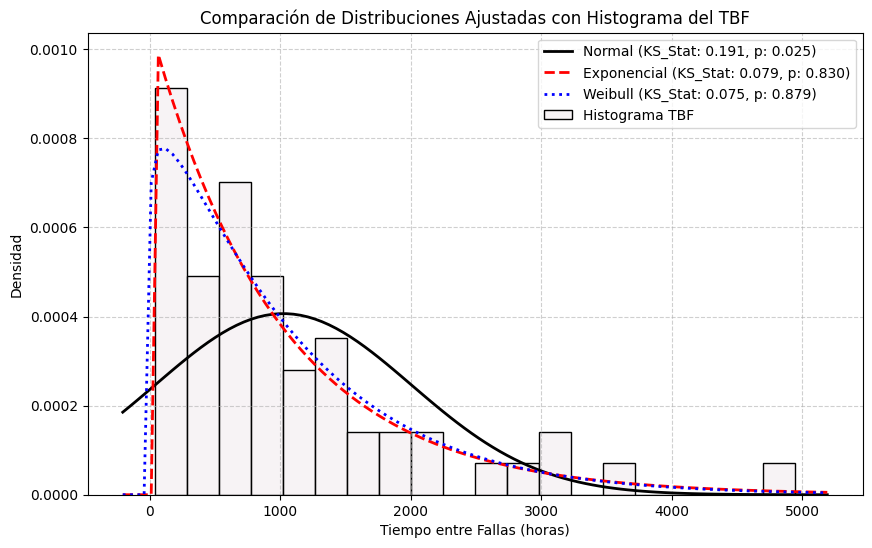

In [9]:
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(transportador, bins=20, kde=False, stat='density', color='#F4EEF1', edgecolor='black', alpha=0.7, label='Histograma TBF')

# Get parameters for the distributions (already fitted in the previous cell)
# Normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x, loc_norm, scale_norm)
plt.plot(x, p_norm, 'k', linewidth=2, label=f'Normal (KS_Stat: {ks_norm_stat:.3f}, p: {ks_norm_pvalue:.3f})')

# Exponential
p_exp = stats.expon.pdf(x, loc_exp, scale_exp)
plt.plot(x, p_exp, 'r--', linewidth=2, label=f'Exponencial (KS_Stat: {ks_exp_stat:.3f}, p: {ks_exp_pvalue:.3f})')

# Weibull
p_weib = stats.weibull_min.pdf(x, beta_weib, loc_weib, eta_weib)
plt.plot(x, p_weib, 'b:', linewidth=2, label=f'Weibull (KS_Stat: {ks_weib_stat:.3f}, p: {ks_weib_pvalue:.3f})')

plt.title('Comparación de Distribuciones Ajustadas con Histograma del TBF')
plt.xlabel('Tiempo entre Fallas (horas)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

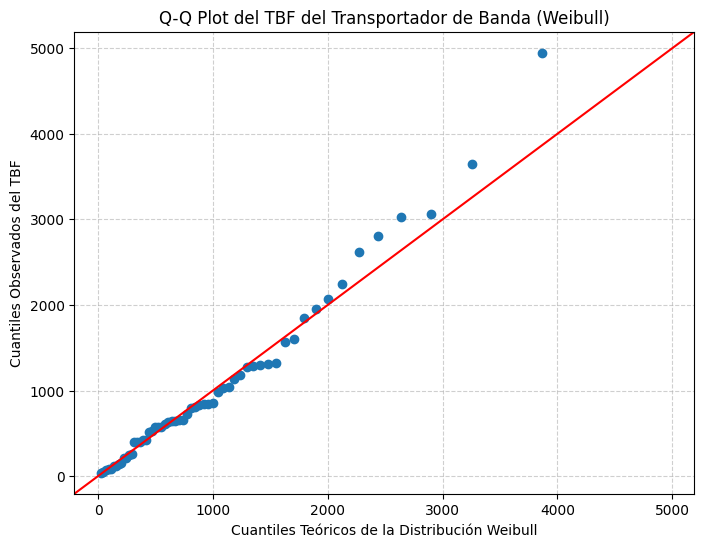

In [10]:
import statsmodels.api as sm

# Create a Q-Q plot for the Weibull distribution
fig, ax = plt.subplots(figsize=(8, 6))

sweibull_dist = stats.weibull_min(beta_weib, loc_weib, eta_weib)

sm.qqplot(transportador, dist=sweibull_dist, line='45', ax=ax)
plt.title('Q-Q Plot del TBF del Transportador de Banda (Weibull)')
plt.xlabel('Cuantiles Teóricos de la Distribución Weibull')
plt.ylabel('Cuantiles Observados del TBF')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Minuto 15-20 · Conclusión

**TODO 4 (obligatorio, 2-3 líneas):** ¿qué distribución ganó?, ¿qué te dice el parámetro de forma sobre cómo falla el Transportador de Banda?, y — conectando con el Paso 1 de la recapitulación — ¿qué decisión de mantenimiento apoyarías con este resultado?

*(Escribe aquí tu conclusión)*

gana la distribucion weibull debido a la prueba  KS en particular  los valores p_value  son los  que  nos  indican la dominancia y con la grafica Q-Q nos da el umbral de analisis  para  la factibilidad  de un mantenimiento predictivo bajo inspecciones basadas en condicion se puede detectar desalineaciones por ejemplo.